# 01 — Synthetic geological model and forward TMI

This notebook builds a **synthetic** Red Lake–style greenstone scenario (mafic lens, felsic intrusion, low-susceptibility shear) on a 3D tensor mesh, lays out an east–west aeromagnetic survey, and generates noisy TMI data for inversion.

**Workflow:** `01_synthetic_model` → `02_inversion` → `03_prospectivity`.

Outputs are saved under `data/processed/` for the inversion notebook.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve().parent
SRC = REPO_ROOT / "src"
sys.path.insert(0, str(SRC))
PROCESSED = REPO_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

from synthetic_model import build_synthetic_mesh, build_true_model, plot_true_model
from forward_sim import (
    build_magnetic_survey,
    build_receiver_grid_ew_lines,
    simulate_tmi,
)
from inversion_setup import build_simulation


In [2]:

# 20 km × 20 km × 5 km depth, 200 m core cells + 6 padding layers (×1.5)
mesh = build_synthetic_mesh(
    extent_xy_m=20_000.0,
    depth_m=5_000.0,
    core_cell_m=200.0,
    padding_cells=6,
    padding_factor=1.5,
)
print("Mesh shape (nCx, nCy, nCz):", tuple(mesh.shape_cells))
print("Total cells:", mesh.n_cells)


Mesh shape (nCx, nCy, nCz): (112, 112, 31)
Total cells: 388864


Mafic cells: 1600
Felsic cells: 1740
Shear cells: 2700
Body cell counts: {'mafic': 1600, 'felsic': 1740, 'shear': 2700}
Assigned susceptibilities: {'background': 0.01, 'mafic': 0.05, 'felsic': 0.0001, 'shear': 0.0001}
Susceptibility range (SI): 0.0001 0.05
plot_true_model slices: ix=55/111, iy=55/111, k_plan=2/30, x=9900.0 m, y=9900.0 m, z_plan=-500.0 m


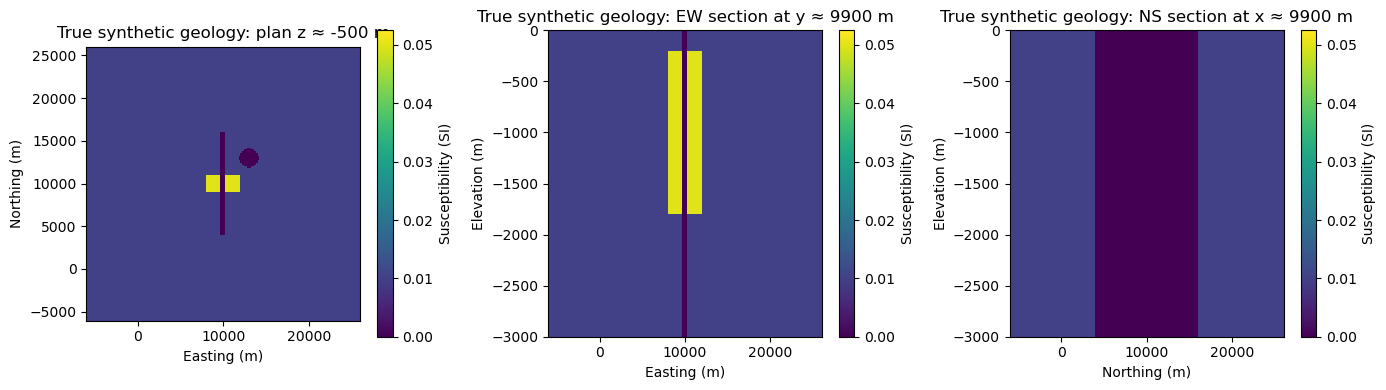

In [3]:

chi_true = build_true_model(mesh)
print("Susceptibility range (SI):", float(chi_true.min()), float(chi_true.max()))
plot_true_model(mesh, chi_true, title_prefix="True synthetic geology")


In [4]:

# E–W lines, 200 m line spacing, 200 m along-line samples, 60 m sensor height
receiver_locs = build_receiver_grid_ew_lines(
    x0=0.0, x1=20_000.0, y0=0.0, y1=20_000.0,
    line_spacing_m=200.0,
    along_line_spacing_m=200.0,
    flight_height_m=60.0,
)
survey = build_magnetic_survey(receiver_locs)
print("Number of stations:", receiver_locs.shape[0])


Number of stations: 10201


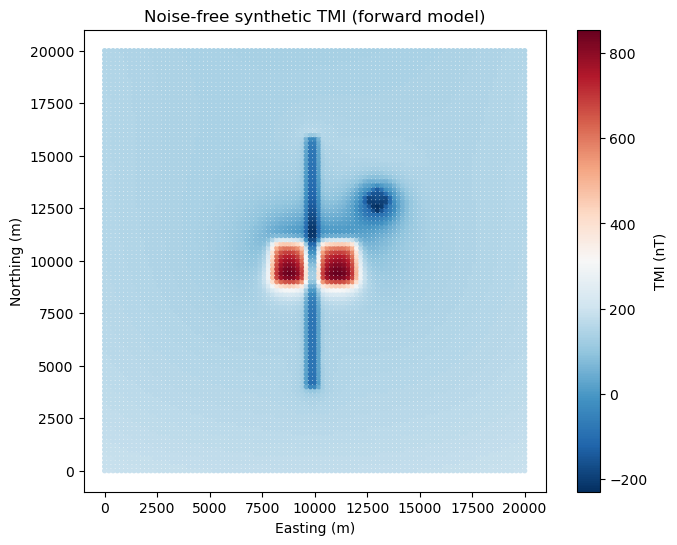

In [5]:

actind = np.ones(mesh.n_cells, dtype=bool)
simulation = build_simulation(
    mesh, survey, actind, store_sensitivities="forward_only"
)
d_clean = simulation.dpred(chi_true)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(receiver_locs[:, 0], receiver_locs[:, 1], c=d_clean, s=8, cmap="RdBu_r")
plt.colorbar(sc, ax=ax, label="TMI (nT)")
ax.set_title("Noise-free synthetic TMI (forward model)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")
plt.show()


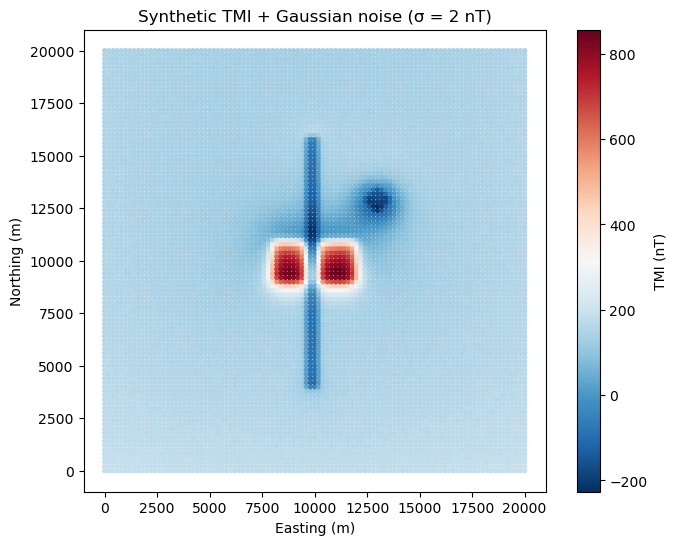

In [6]:

data_syn = simulate_tmi(
    mesh, chi_true, survey, actind=actind, noise_std_nt=2.0, random_seed=42, simulation=simulation
)
d_noisy = data_syn.dobs

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(receiver_locs[:, 0], receiver_locs[:, 1], c=d_noisy, s=8, cmap="RdBu_r")
plt.colorbar(sc, ax=ax, label="TMI (nT)")
ax.set_title("Synthetic TMI + Gaussian noise (σ = 2 nT)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")
plt.show()


In [7]:

np.save(PROCESSED / "chi_true.npy", chi_true)
np.savez(
    PROCESSED / "synthetic_survey.npz",
    receiver_locations=receiver_locs,
    dobs=data_syn.dobs,
    standard_deviation=data_syn.standard_deviation,
    random_seed=42,
)
print("Saved:", PROCESSED / "chi_true.npy")
print("Saved:", PROCESSED / "synthetic_survey.npz")


Saved: /Users/shawngabriel/Documents/Projects/Magnetic-Susceptibility-Inversion/data/processed/chi_true.npy
Saved: /Users/shawngabriel/Documents/Projects/Magnetic-Susceptibility-Inversion/data/processed/synthetic_survey.npz
